<a href="https://colab.research.google.com/github/Umama123/Machine-Learning/blob/main/ML_A_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Generate Synthetic Data**

•	Create a small dataset for linear regression using the equation:

     y=3x + 5 + noise

•	The dataset consists of 100 points with random noise added.

•	Prints the first few generated (x, y) pairs.


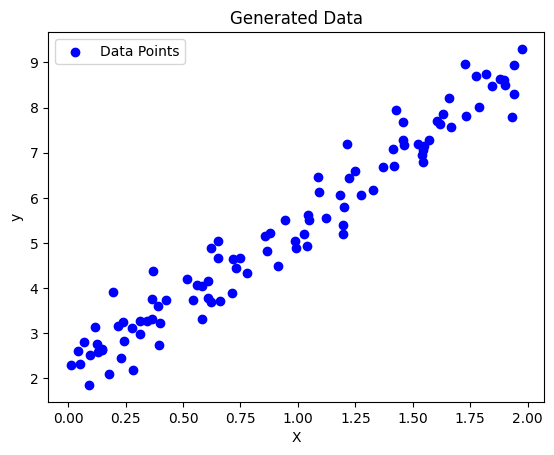

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate Dataset
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 3.5 * X + 2 + np.random.randn(100, 1) * 0.5

plt.scatter(X, y, color='blue', label='Data Points')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.legend()
plt.show()

**Implement Stochastic Gradient Descent (SGD)**

The function stochastic_gradient_descent(X, y, lr=0.01, epochs=50) optimizes the linear regression parameters using Stochastic Gradient Descent (SGD).

Stochastic Gradient Descent (SGD) updates the model parameters (m and b) one random data point at a time, rather than using the whole dataset. This makes the updates faster but noisier, helping the model learn efficiently, especially for large datasets.


In [7]:
# Step 2: Define Mean Squared Error Function
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [9]:
# Step 3: Implement Stochastic Gradient Descent (SGD)
def stochastic_gradient_descent(X, y, lr=0.01, epochs=50):
    m, b = np.random.randn(), np.random.randn()  # Initialize parameters
    losses = []
    n = len(y)

    for epoch in range(epochs):
        for i in range(n):
            rand_idx = np.random.randint(n)
            xi, yi = X[rand_idx], y[rand_idx]

            y_pred = m * xi + b
            gradient_m = -2 * xi * (yi - y_pred)
            gradient_b = -2 * (yi - y_pred)

            m -= lr * gradient_m
            b -= lr * gradient_b

        loss = mse(y, m * X + b)
        losses.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss}")

    return m, b, losses

Epoch 0: Loss = 0.5037095067649922
Epoch 10: Loss = 0.21987341608143043
Epoch 20: Loss = 0.20542666640216947
Epoch 30: Loss = 0.2135310492861955
Epoch 40: Loss = 0.21949685182251483


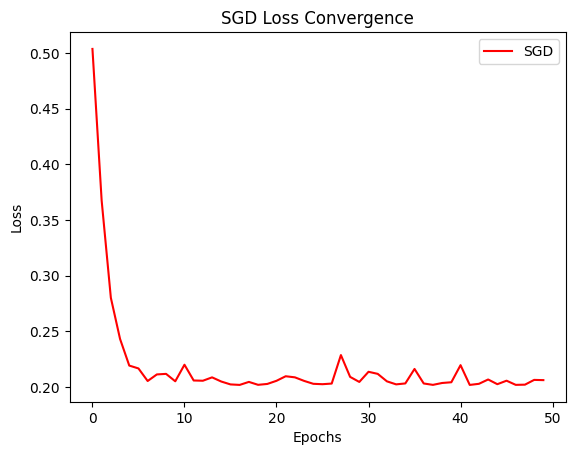

In [10]:
# Step 4: Train the Model Using SGD
m_sgd, b_sgd, losses_sgd = stochastic_gradient_descent(X, y, lr=0.01, epochs=50)

# Step 5: Plot Loss Convergence for SGD
plt.plot(losses_sgd, label='SGD', color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SGD Loss Convergence")
plt.legend()
plt.show()


**Batch Gradient Descent (BGD)**

The code implements Batch Gradient Descent (BGD) to train a linear regression model. It iteratively updates the model parameters (`m` and `b`) by calculating the gradients of the Mean Squared Error (MSE) loss function and adjusting the parameters to minimize the error. The process continues for a specified number of epochs, and the loss at each epoch is tracked and printed periodically. Finally, it returns the learned parameters (`m` and `b`) and the loss history.

In [11]:
# Step 6: Implement Batch Gradient Descent (BGD)
def batch_gradient_descent(X, y, lr=0.01, epochs=50):
    m, b = np.random.randn(), np.random.randn()
    losses = []
    n = len(y)

    for epoch in range(epochs):
        y_pred = m * X + b
        gradient_m = (-2 / n) * np.sum(X * (y - y_pred))
        gradient_b = (-2 / n) * np.sum(y - y_pred)

        m -= lr * gradient_m
        b -= lr * gradient_b

        loss = mse(y, m * X + b)
        losses.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss}")

    return m, b, losses

# Step 7: Train the Model Using BGD
m_bgd, b_bgd, losses_bgd = batch_gradient_descent(X, y, lr=0.01, epochs=50)

Epoch 0: Loss = 18.1776110322911
Epoch 10: Loss = 8.073535381199804
Epoch 20: Loss = 3.71783295968821
Epoch 30: Loss = 1.8355626396911133
Epoch 40: Loss = 1.0178729291234925


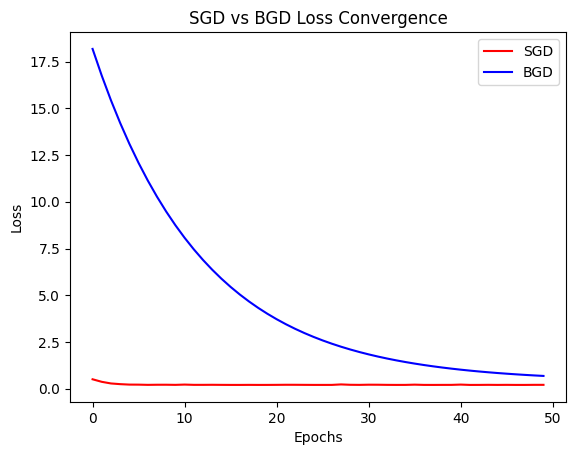

In [12]:
# Step 8: Compare Convergence Between SGD and BGD
plt.plot(losses_sgd, label='SGD', color='red')
plt.plot(losses_bgd, label='BGD', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SGD vs BGD Loss Convergence")
plt.legend()
plt.show()

 **SGD vs BGD Loss Convergence graph:**

SGD outperforms BGD. It starts with lower loss (~0.5 vs ~18), maintains consistently low values throughout training, and ends with better final optimization. While BGD eventually improves, it never catches up to SGD's efficiency.

**Mini-Batch Gradient Descent**

This code implements Mini-Batch Gradient Descent (MBGD), which:
- Randomly shuffles the dataset at each epoch
- Processes data in small batches (10 samples) rather than one sample (SGD) or all data (BGD)
- Updates model parameters after each batch using gradient calculations
- Tracks loss for each epoch to monitor convergence



In [13]:
# Step 9: Implement Mini-Batch Gradient Descent
def mini_batch_gradient_descent(X, y, lr=0.01, epochs=50, batch_size=10):
    m, b = np.random.randn(), np.random.randn()
    losses = []
    n = len(y)

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled, y_shuffled = X[indices], y[indices]

        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            y_pred = m * X_batch + b
            gradient_m = (-2 / batch_size) * np.sum(X_batch * (y_batch - y_pred))
            gradient_b = (-2 / batch_size) * np.sum(y_batch - y_pred)

            m -= lr * gradient_m
            b -= lr * gradient_b

        loss = mse(y, m * X + b)
        losses.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss}")

    return m, b, losses

# Step 10: Train the Model Using Mini-Batch GD
m_mbgd, b_mbgd, losses_mbgd = mini_batch_gradient_descent(X, y, lr=0.01, epochs=50, batch_size=10)

Epoch 0: Loss = 13.15652528175374
Epoch 10: Loss = 0.2314309103636872
Epoch 20: Loss = 0.21540482838749436
Epoch 30: Loss = 0.20860518761409297
Epoch 40: Loss = 0.20516467333593777


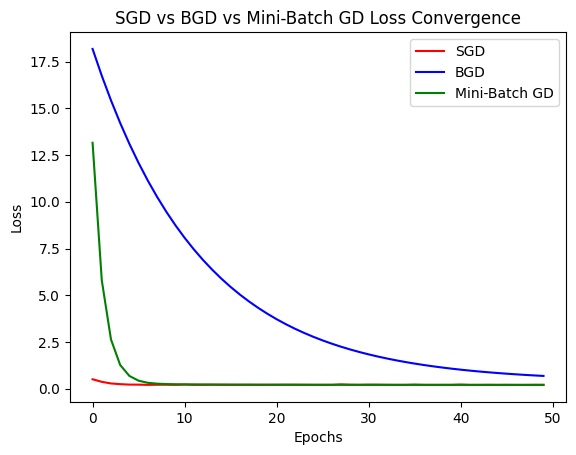

In [14]:
# Step 11: Compare All Three Methods
plt.plot(losses_sgd, label='SGD', color='red')
plt.plot(losses_bgd, label='BGD', color='blue')
plt.plot(losses_mbgd, label='Mini-Batch GD', color='green')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SGD vs BGD vs Mini-Batch GD Loss Convergence")
plt.legend()
plt.show()


# New Section
**SGD VS MBGD VS BGD**

Based on this graph comparing all three gradient descent methods:

SGD (red) is the most efficient overall, starting with the lowest initial loss (~0.5) and maintaining it throughout training.

Mini-Batch GD (green) shows impressive performance, starting higher than SGD (~13) but converging extremely rapidly (within ~5 epochs) to match SGD's low loss.

BGD (blue) performs worst, starting highest (~18) and converging much more slowly than the others, never quite reaching their optimization level even after 50 epochs.

